In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd

import librosa
import librosa.display

import matplotlib.pyplot as plt

from scipy.stats import entropy
from scipy.signal import welch

from tqdm import tqdm

plt.rcParams["figure.figsize"] = (12,5)
plt.rcParams["font.size"] = 12

In [2]:
# ==========================================================
# DATASET PATHS
# ==========================================================

VOICEBANK = {
    "clean": "/home/dsi/skopavi/Project/kws_project/code/sgmse/data/datasets/jweiqi/voicebank-demand-16k/versions/1/clean_trainset_28spk_wav",
    "noisy": "/home/dsi/skopavi/Project/kws_project/code/sgmse/data/datasets/jweiqi/voicebank-demand-16k/versions/1/clean_trainset_28spk_wav"
}

OURS = {
    "clean": "/home/dsi/skopavi/Project/kws_project/data/train_sgmse/train/clean",
    "noisy": "/home/dsi/skopavi/Project/kws_project/data/train_sgmse/train/noisy"
}

SR = 16000

N_RANDOM = 5

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [3]:
# HELPER FUNCTIONS

def get_wavs(folder):

    return sorted(Path(folder).glob("*.wav"))

def load_audio(path):

    audio, sr = librosa.load(path, sr=SR)

    return audio

def extract_noise(clean, noisy):

    return noisy - clean

def duration_seconds(path):

    return librosa.get_duration(path=path)

In [4]:
def dataset_statistics(dataset):

    clean_files = get_wavs(dataset["clean"])

    durations = []

    for file in clean_files:

        durations.append(duration_seconds(file))

    durations = np.array(durations)

    return pd.Series({

        "Files": len(clean_files),

        "Total Hours": durations.sum()/3600,

        "Average Duration (sec)": durations.mean(),

        "Median Duration (sec)": np.median(durations),

        "Min Duration (sec)": durations.min(),

        "Max Duration (sec)": durations.max()

    })

In [5]:
summary = pd.DataFrame({

    "VoiceBank": dataset_statistics(VOICEBANK),

    "Our Dataset": dataset_statistics(OURS)

})

display(summary)

,VoiceBank,Our Dataset
Files,11572.000000,6150.000000
Total Hours,9.391286,1.677301
Average Duration (sec),2.921589,0.981835
Median Duration (sec),2.678750,1.000000
Min Duration (sec),1.092375,0.464438
Max Duration (sec),15.112063,1.000000


In [6]:
voice_durations = [
    duration_seconds(f)
    for f in get_wavs(VOICEBANK["clean"])
]

our_durations = [
    duration_seconds(f)
    for f in get_wavs(OURS["clean"])
]

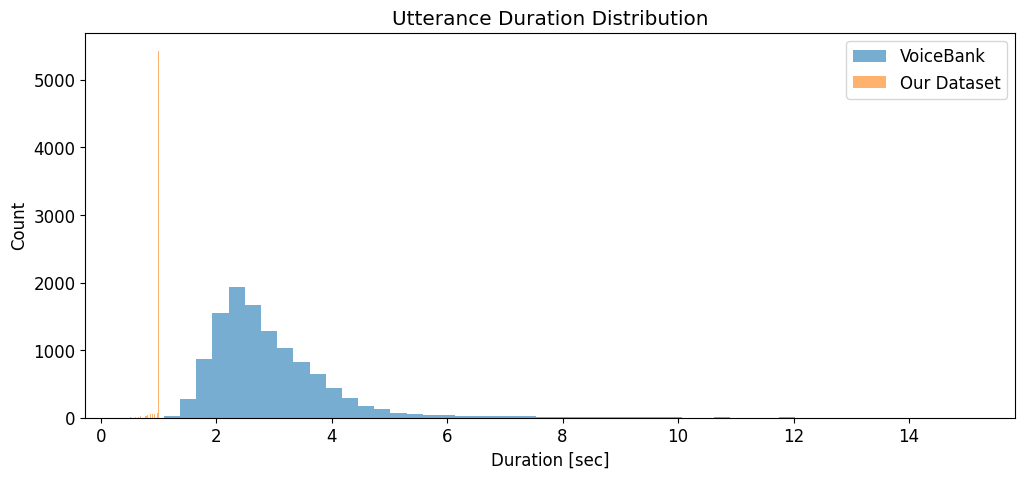

In [7]:
plt.figure(figsize=(12,5))

plt.hist(
    voice_durations,
    bins=50,
    alpha=0.6,
    label="VoiceBank"
)

plt.hist(
    our_durations,
    bins=50,
    alpha=0.6,
    label="Our Dataset"
)

plt.xlabel("Duration [sec]")
plt.ylabel("Count")

plt.legend()

plt.title("Utterance Duration Distribution")

plt.show()

In [8]:
voice_files = get_wavs(VOICEBANK["clean"])

idx = random.randint(0, len(voice_files)-1)

voice_clean = load_audio(
    voice_files[idx]
)

voice_noisy = load_audio(
    Path(VOICEBANK["noisy"]) / voice_files[idx].name
)

voice_noise = extract_noise(
    voice_clean,
    voice_noisy
)

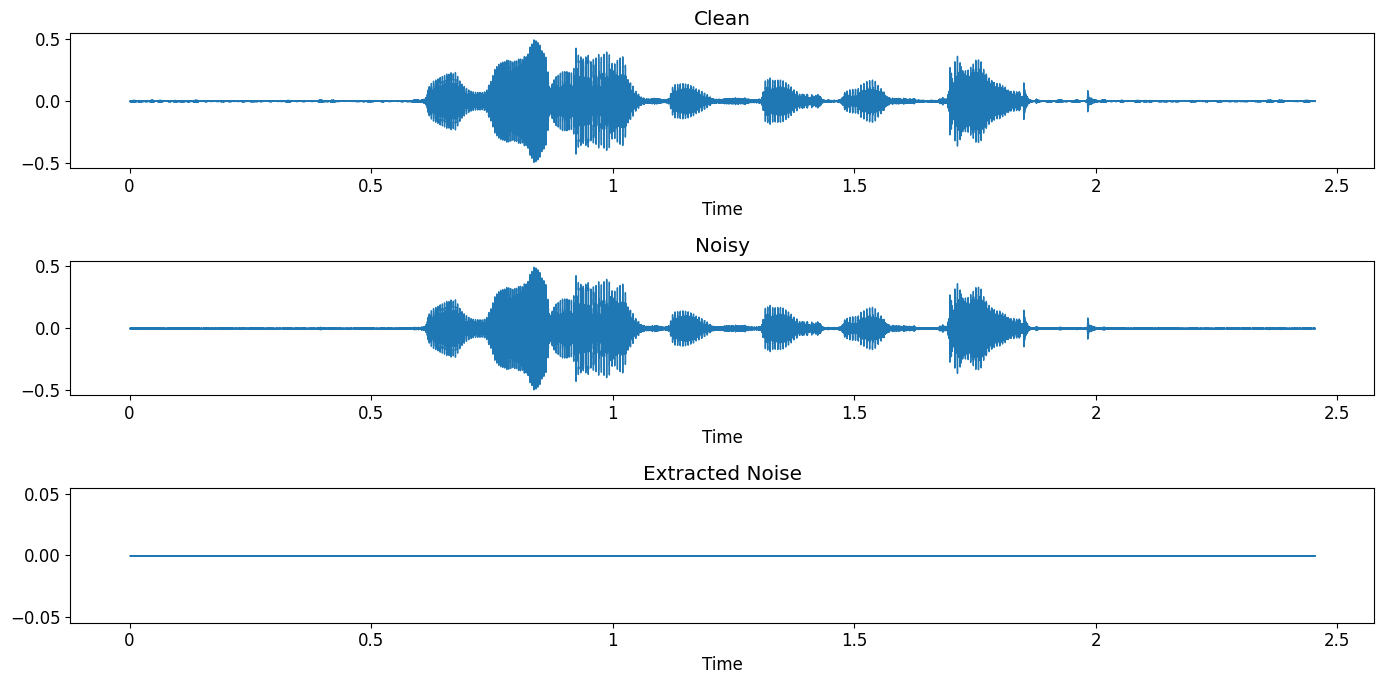

In [10]:
fig, ax = plt.subplots(3,1, figsize=(14,7))

librosa.display.waveshow(
    voice_clean,
    sr=SR,
    ax=ax[0]
)

ax[0].set_title("Clean")

librosa.display.waveshow(
    voice_noisy,
    sr=SR,
    ax=ax[1]
)

ax[1].set_title("Noisy")

librosa.display.waveshow(
    voice_noise,
    sr=SR,
    ax=ax[2]
)

ax[2].set_title("Extracted Noise")

plt.tight_layout()

plt.show()

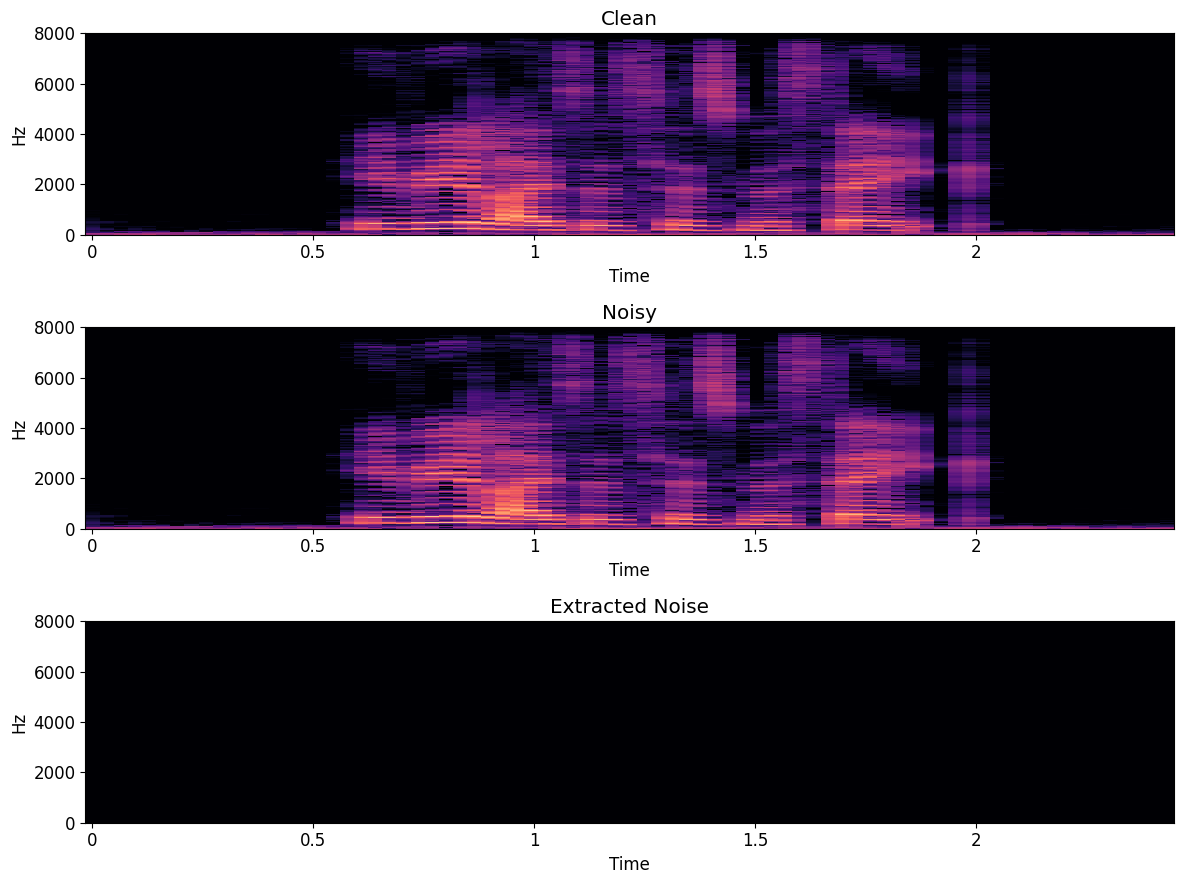

In [11]:
signals = {

    "Clean": voice_clean,

    "Noisy": voice_noisy,

    "Extracted Noise": voice_noise

}

fig, axes = plt.subplots(3,1, figsize=(12,9))

for ax, (title, signal) in zip(axes, signals.items()):

    D = librosa.amplitude_to_db(
        np.abs(
            librosa.stft(signal)
        ),
        ref=np.max
    )

    librosa.display.specshow(

        D,

        sr=SR,

        x_axis="time",

        y_axis="hz",

        ax=ax

    )

    ax.set_title(title)

plt.tight_layout()

plt.show()